In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
df_tc_labels = pd.read_csv('../data/raw/medical_tc_labels.csv')
df_tc_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   condition_label  5 non-null      int64
 1   condition_name   5 non-null      str  
dtypes: int64(1), str(1)
memory usage: 212.0 bytes


In [141]:
df_tc_labels.head(5)

,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


In [142]:
df_tc_test = pd.read_csv('../data/raw/medical_tc_test.csv')
df_tc_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   condition_label   2888 non-null   int64
 1   medical_abstract  2888 non-null   str  
dtypes: int64(1), str(1)
memory usage: 45.3 KB


In [143]:
x = df_tc_test.groupby('condition_label')['medical_abstract'].count()
print(x)

condition_label
1    633
2    299
3    385
4    610
5    961
Name: medical_abstract, dtype: int64


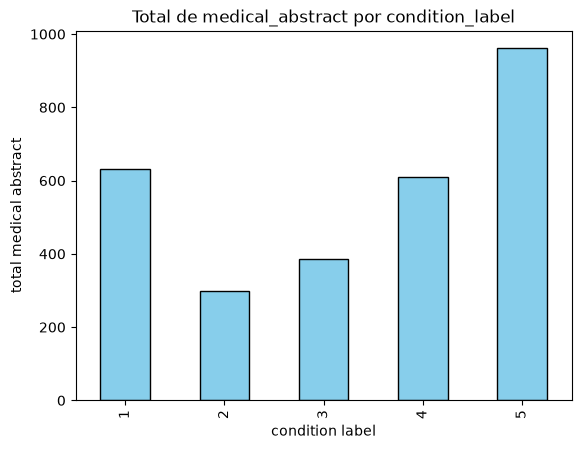

In [144]:
x.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Total de medical_abstract por condition_label")
plt.xlabel("condition label")
plt.ylabel("total medical abstract")
plt.tight_layout
plt.show()

C:\Users\lara-\AppData\Local\Temp\ipykernel_18572\2744643984.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tc_test, x='condition_label',palette='pastel')


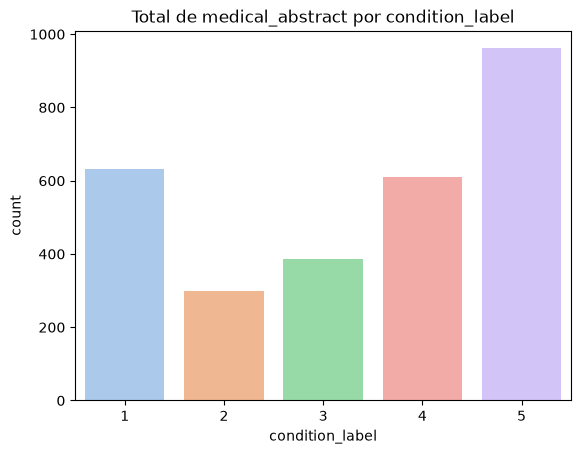

In [145]:
sns.countplot(data=df_tc_test, x='condition_label',palette='pastel')
plt.title("Total de medical_abstract por condition_label")
plt.show()

In [146]:
df_tc_train = pd.read_csv('../data/raw/medical_tc_train.csv')
df_tc_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 11550 entries, 0 to 11549
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   condition_label   11550 non-null  int64
 1   medical_abstract  11550 non-null  str  
dtypes: int64(1), str(1)
memory usage: 180.6 KB


C:\Users\lara-\AppData\Local\Temp\ipykernel_18572\2043692707.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tc_train, x='condition_label',palette='pastel')


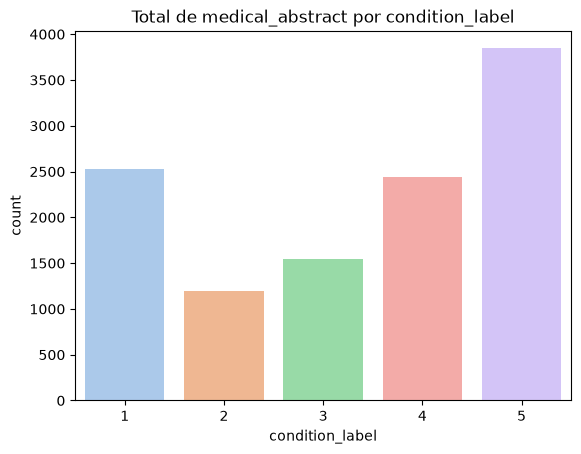

In [147]:
sns.countplot(data=df_tc_train, x='condition_label',palette='pastel')
plt.title("Total de medical_abstract por condition_label")
plt.show()

In [148]:
df_train_merge = df_tc_train.merge(df_tc_labels, how='inner', on='condition_label')
df_train_merge.to_csv('../data/processed/df_train_merged.csv')

In [149]:
df_test_merge = df_tc_test.merge(df_tc_labels, how='inner', on='condition_label')
df_test_merge.to_csv('../data/processed/df_test_merged.csv')

In [150]:
import spacy
nlp = spacy.load("en_core_web_sm")
print(nlp)

In [151]:
documento = nlp("im learnin english")
documento

im learnin english

In [152]:
for token in documento:
    print(token.text, token.pos_)

i PRON
m VERB
learnin ADJ
english PROPN


Lematização: lema de uma palavra de acordo com seu significado no dicionarios
Stemização: extrair o radical das palavras

In [153]:
documento_df = nlp(str(df_train_merge['medical_abstract']))

In [154]:
for token in documento_df:
    print(token.text, token.pos_)

0 NUM
        SPACE
Tissue PROPN
changes NOUN
around ADP
loose ADJ
prostheses NOUN
. PUNCT
A DET
cani NOUN
... PUNCT

 SPACE
1 NUM
        SPACE
Neuropeptide PROPN
Y PROPN
and CCONJ
neuron NOUN
- PUNCT
specific ADJ
enolase NOUN
lev NOUN
... PUNCT

 SPACE
2 NUM
        SPACE
Sexually ADV
transmitted VERB
diseases NOUN
of ADP
the DET
colon NOUN
, PUNCT
re NOUN
... PRON

 SPACE
3 NUM
        SPACE
Lipolytic ADJ
factors NOUN
associated VERB
with ADP
murine NOUN
and CCONJ
h PROPN
... PUNCT

 SPACE
4 NUM
        SPACE
Does AUX
carotid NOUN
restenosis NOUN
predict VERB
an DET
increased VERB
r NOUN
... PUNCT

                                SPACE
... PUNCT
                       
 SPACE
11545 NUM
    SPACE
Epirubicin PROPN
at ADP
two NUM
dose NOUN
levels NOUN
with ADP
prednisolon NOUN
... PUNCT

 SPACE
11546 NUM
    SPACE
Four NUM
and CCONJ
a DET
half NOUN
year NOUN
follow VERB
up ADP
of ADP
women NOUN
with ADP
d PROPN
... PUNCT

 SPACE
11547 NUM
    SPACE
Safety PROPN
of ADP
the DET
transbron

Reconhecendo entidades nomeadas

NER - named-entity recognition: encontrar entidades no textto

In [155]:
documento_df = nlp(str(df_train_merge['medical_abstract']))

for entidade in documento_df.ents:
    print(entidade.text, entidade.label_)

0 CARDINAL
2 CARDINAL
3 CARDINAL
4 CARDINAL
11545 DATE
two CARDINAL
11546 DATE
Four and a half year DATE
11547 DATE
outpati GPE
11548 CARDINAL
11549 CARDINAL
first ORDINAL
11550 DATE


In [156]:
from spacy import displacy
displacy.render(documento_df, style='ent', jupyter=True)

In [157]:
documento_df = nlp(str(df_train_merge['medical_abstract']))

for entidade in documento_df.ents:
    print(entidade.text, entidade.label_)

0 CARDINAL
2 CARDINAL
3 CARDINAL
4 CARDINAL
11545 DATE
two CARDINAL
11546 DATE
Four and a half year DATE
11547 DATE
outpati GPE
11548 CARDINAL
11549 CARDINAL
first ORDINAL
11550 DATE


In [158]:
from spacy import displacy
displacy.render(documento_df, style='ent', jupyter=True)

In [159]:
import nltk
nltk.download('rslp')

[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\lara-\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

In [160]:
stemmet = nltk.stem.RSLPStemmer()
stemmet.stem('aprendendo')

'aprend'

In [161]:
for token in documento_df:
    print(token.text, token.lemma, stemmet.stem(token.text))

0 746762829127501960 0
        8732073009930279273        
Tissue 13217482955804178189 tissu
changes 3979101002134440957 chang
around 3194226484742107227 around
loose 7026361847554578715 loos
prostheses 14878165642793746161 prosthes
. 12646065887601541794 .
A 11901859001352538922 a
cani 15392214927449916839 can
... 10875615029400813363 ...

 962983613142996970 

1 5533571732986600803 1
        8732073009930279273        
Neuropeptide 16403457585148006167 neuropeptid
Y 16961793518281001049 y
and 2283656566040971221 and
neuron 10452704660894501306 neuron
- 9153284864653046197 -
specific 12164866545557247138 specific
enolase 5017822019143885595 enolas
lev 10524141904549046167 lev
... 10875615029400813363 ...

 962983613142996970 

2 15180167692696242062 2
        8732073009930279273        
Sexually 17511750081972337329 sexually
transmitted 4375482739877099638 transmitted
diseases 5781322434961390358 diseas
of 886050111519832510 of
the 7425985699627899538 the
colon 348548765197339401 colo

In [162]:
# stopwords = palavras que nao agregam
from spacy.lang.en.stop_words import STOP_WORDS
len(STOP_WORDS)

326

In [163]:
nlp.vocab['would'].is_stop

True

In [164]:
# Funções de pre processamento: retirada e pontuações, remocao de stop words
from spacy.lang.en.stop_words import STOP_WORDS
import string

stop_words = STOP_WORDS
print(stop_words)

pontuacoes = string.punctuation
print(pontuacoes)

{'‘s', 'six', 'eight', 'anything', 'whereafter', 'three', "'m", 'otherwise', 'hereafter', 'further', 'the', 'indeed', 'within', 'before', '‘d', 'really', 'via', 'amount', 'below', 'onto', 'either', 'off', 'twelve', 'someone', 'also', 'used', 'please', 'meanwhile', 'due', 'may', '’ll', 'towards', 'quite', 'along', 'itself', 'five', 'many', 'yours', 'whatever', 'seem', 'sometimes', "'ve", 'make', 'how', "'ll", 'sixty', 'as', 'whom', 'too', 'mine', 'herein', 'one', 'again', 'ten', 'such', 'could', 'take', 'of', 'four', 'already', 'though', '’re', 'where', 'everywhere', '‘m', 'fifteen', 'around', 'there', 'himself', 'must', 'namely', 'he', 'else', 'out', 'here', 'own', 'enough', 'neither', 'is', 'what', 'between', 'made', 'almost', 'nine', 'keep', 'you', 'anyway', 'go', 'have', 'former', 'yourselves', 'moreover', '‘ll', 'other', 'often', 'first', 'his', 'so', 'once', 'both', 'by', 'nowhere', 'alone', 'now', 'since', 'always', 'therein', 'toward', 'most', 'this', 'be', 'anyhow', 'front', 'w

In [165]:
len(stop_words)

326

In [166]:
pln = spacy.load("en_core_web_sm")
pln

In [167]:
def pre_processamento(texto):
    texto = texto.lower()
    documento = pln(texto)

    lista = []
    for token in documento:
        lista.append(token.lemma_)

    lista = [palavra for palavra in lista if palavra not in stop_words and palavra not in pontuacoes]
    lista = ' '.join([str(elemento) for elemento in lista if not elemento.isdigit()])
    return lista

In [168]:
teste = pre_processamento('im learning, the english ; ')

print(teste)

I m learn english


In [169]:
df_train_merge.head(10)

,condition_label,medical_abstract,condition_name
0,5,Tissue changes around loose prostheses. A cani...,general pathological conditions
1,1,Neuropeptide Y and neuron-specific enolase lev...,neoplasms
2,2,"Sexually transmitted diseases of the colon, re...",digestive system diseases
3,1,Lipolytic factors associated with murine and h...,neoplasms
4,3,Does carotid restenosis predict an increased r...,nervous system diseases
5,3,The shoulder in multiple epiphyseal dysplasia....,nervous system diseases
6,2,The management of postoperative chylous ascite...,digestive system diseases
7,4,Pharmacomechanical thrombolysis and angioplast...,cardiovascular diseases
8,5,Color Doppler diagnosis of mechanical prosthet...,general pathological conditions
9,5,Noninvasive diagnosis of right-sided extracard...,general pathological conditions


In [170]:
df_train_merge['medical_abstract']  = df_train_merge['medical_abstract'].apply(pre_processamento)

In [171]:
df_train_merge.to_csv('../data/processed/df_train_preprocessed.csv')

In [172]:
df_train_preprocessed = pd.read_csv('../data/processed/df_train_preprocessed.csv')
df_train_preprocessed.head(10)

,Unnamed: 0,condition_label,medical_abstract,condition_name
0,0,5,tissue change loose prosthesis canine model in...,general pathological conditions
1,1,1,neuropeptide y neuron specific enolase level b...,neoplasms
2,2,2,sexually transmit disease colon rectum anus ch...,digestive system diseases
3,3,1,lipolytic factor associate murine human cancer...,neoplasms
4,4,3,carotid restenosis predict increase risk late ...,nervous system diseases
5,5,3,shoulder multiple epiphyseal dysplasia shoulde...,nervous system diseases
6,6,2,management postoperative chylous ascite case r...,digestive system diseases
7,7,4,pharmacomechanical thrombolysis angioplasty ma...,cardiovascular diseases
8,8,5,color doppler diagnosis mechanical prosthetic ...,general pathological conditions
9,9,5,noninvasive diagnosis right sided extracardiac...,general pathological conditions


In [173]:
df_train_final = []

for medical_abstract, condition_name in zip(df_train_preprocessed['medical_abstract'], df_train_preprocessed['condition_name']):
    if condition_name == 'neoplasms':
        dic = ({'neoplasms': True, 'digestive system diseases': False, 'nervous system diseases':False, 'cardiovascular diseases': False, 'general pathological conditions': False})
    elif condition_name == 'digestive system diseases':
        dic = ({'neoplasms': False, 'digestive system diseases': True, 'nervous system diseases':False, 'cardiovascular diseases': False, 'general pathological conditions': False})   
    elif condition_name == 'nervous system diseases':
            dic = ({'neoplasms': False, 'digestive system diseases': False, 'nervous system diseases':True, 'cardiovascular diseases': False, 'general pathological conditions': False})
    elif condition_name == 'cardiovascular diseases':
                dic = ({'neoplasms': False, 'digestive system diseases': False, 'nervous system diseases':False, 'cardiovascular diseases': True, 'general pathological conditions': False})
    elif condition_name == 'general pathological conditions':
                dic = ({'neoplasms': False, 'digestive system diseases': False, 'nervous system diseases':False, 'cardiovascular diseases': False, 'general pathological conditions': True})     

    df_train_final.append([medical_abstract, dic.copy()])             

In [186]:
df_train_final[0][1]

{'neoplasms': False,
 'digestive system diseases': False,
 'nervous system diseases': False,
 'cardiovascular diseases': False,
 'general pathological conditions': True}

In [189]:
type(df_train_final[0][1])

dict

In [192]:
modelo = spacy.blank('en')

categorias = modelo.add_pipe('textcat', last=True)
categorias.add_label('neoplasms')
categorias.add_label('digestive system diseases')
categorias.add_label('nervous system diseases')
categorias.add_label('cardiovascular diseases')
categorias.add_label('general pathological conditions')

historico = []


In [ ]:
import random
import spacy
from spacy.training.example import Example

modelo = spacy.blank("en")

# Inicializar otimizador
optimizer = modelo.initialize()

for epoca in range(1000):
    random.shuffle(df_train_final)
    losses = {}

    # Criar batches
    for batch in spacy.util.minibatch(df_train_final, size=128):
        examples = []
        for texto, entities in batch:
            doc = modelo.make_doc(texto)
            # Agora usamos Example.from_dict para criar o exemplo com as anotações
            examples.append(Example.from_dict(doc, {"cats": entities}))

        # Atualizar o modelo com os exemplos
        modelo.update(examples, sgd=optimizer, losses=losses)

    if epoca % 100 == 0:
        print(losses)
        historico.append(losses)


{}
{}
{}
{}
{}
{}
{}
{}


In [ ]:
historico_loss = []
for i in historico:
    historico_loss.append(i.get('textcat'))

In [ ]:
import numpy as np
historico_loss = np.array(historico_loss)
historico_loss

In [ ]:
import matplotlib.pyplot as plt
plt.plot(historico_loss)
plt.title('progressao do erro')
plt.xlabel('epocas')
plt.ylabel('erro')

In [ ]:
modelo.to_disk('modelo')